# Metric Identifiability Analysis for SED Reasoning

> **“Waste no more time arguing what a good man should be. Be one.”**  
> — *Marcus Aurelius, Meditations* 10.16


## Overview

This notebook provides an empirical analysis of **metric identifiability** in LLM reasoning evaluation, operationalizing the theoretical framework from `report/metric-identifiability-llm-reasoning/`.

It is intended as the *capstone* analysis notebook: `disagreement_mass.ipynb` introduces the disagreement-mass diagnostic in isolation, and this notebook integrates it with the full set of pathology + Goodhart-style analyses.

### Key Questions

1. **Syntax vs Semantics**: Does syntactic validity predict semantic correctness?
2. **Three Pathologies**: Do our metrics exhibit length, validity, or progress bias?
3. **Identifiability**: Can we recover latent competence from observed metrics?
4. **Goodhart's Law**: Are proxy metrics diverging from the true objective?

### Document Structure

| Section | Topic |
|---------|-------|
| 1 | Data Loading & Formalization |
| 2 | Syntax vs Semantics Analysis |
| 3 | Metric Pathology Detection |
| 4 | Disagreement Mass & Identifiability |
| 5 | Goodhart's Law Empirical Test |
| 6 | Implications & Conclusions |


In [12]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Professional styling
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'

COLORS = {
    'correct': '#2ecc71', 'incorrect': '#e74c3c',
    'valid': '#3498db', 'invalid': '#95a5a6',
    'easy': '#2ecc71', 'medium': '#f39c12', 'hard': '#e74c3c',
}

print("📊 Metric Identifiability Analysis")


📊 Metric Identifiability Analysis


---

## 1. Data Loading & SED Formalization

### Problem Definition

An SED puzzle is a 3-tuple $\mathcal{P} = (s_0, \mathcal{T}, \varepsilon)$ where:

- $s_0 \in \Sigma^*$ is the initial string
- $\mathcal{T} = \{t_1, ..., t_n\}$ is a set of rewrite rules $\alpha_i \to \beta_i$
- $\varepsilon$ (empty string) is the goal state

### Key Non-Implication

$$\text{valid}(Y) \not\Rightarrow \text{correct}(Y)$$

Valid steps do not guarantee task success.


In [13]:
# Load evaluation data
base_path = Path('..')
metrics_file = base_path / 'results' / 'metrics_full_analysis.csv'

df = pd.read_csv(metrics_file)
df['is_correct'] = df['is_correct'].apply(lambda x: x == 'True' if isinstance(x, str) else bool(x))
df['output_length'] = df['total_steps']

print(f"📋 Loaded {len(df)} evaluation records")
print(f"🎯 Models: {df['model'].unique().tolist()}")
print(f"📝 Prompt types: {df['prompt_type'].unique().tolist()}")
print(f"📊 Difficulty levels: {df['difficulty'].unique().tolist()}")
print(f"\n📈 Correctness rate: {df['is_correct'].mean()*100:.1f}%")
print(f"📈 Mean valid steps ratio: {df['valid_steps_ratio'].mean():.3f}")
print(f"📈 Mean progress score: {df['progress_score'].mean():.3f}")


📋 Loaded 480 evaluation records
🎯 Models: ['LLaMA 3.1 8B', 'LLaMA 3.3 70B', 'LLaMA 4 Scout']
📝 Prompt types: ['Role-Classify', 'CoT', 'Few-Shot', 'Zero-Shot', 'Self-Verify']
📊 Difficulty levels: ['medium', 'hard', 'easy']

📈 Correctness rate: 50.8%
📈 Mean valid steps ratio: 0.710
📈 Mean progress score: 0.712


---

## 2. Syntax vs Semantics Analysis

### The Fundamental Distinction

| Aspect | Syntax | Semantics |
|--------|--------|-----------|
| Question | Is this step allowed? | Does this sequence solve the task? |
| Scope | Local (single step) | Global (entire computation) |
| Verification | Check rule applicability | Execute and verify final state |

### The Core Problem

$$\forall i: a_i \in \mathcal{A}(s_{i-1}) \quad \not\Rightarrow \quad s_n \in G$$

Every step can be valid, yet the final result can be wrong.


In [14]:
# Analyze the syntax-semantics gap
high_validity_threshold = 0.8
high_validity_mask = df['valid_steps_ratio'] >= high_validity_threshold
high_validity_incorrect = high_validity_mask & ~df['is_correct']

n_high_validity = high_validity_mask.sum()
n_high_validity_incorrect = high_validity_incorrect.sum()

print("=" * 70)
print("SYNTAX vs SEMANTICS GAP ANALYSIS")
print("=" * 70)

print(f"\n📊 Cases with high syntactic validity (≥{high_validity_threshold:.0%}):")
print(f"   Total: {n_high_validity} ({n_high_validity/len(df)*100:.1f}% of all evaluations)")
print(f"   Correct: {(high_validity_mask & df['is_correct']).sum()}")
print(f"   Incorrect: {n_high_validity_incorrect}")

if n_high_validity > 0:
    p_correct_given_high_validity = df.loc[high_validity_mask, 'is_correct'].mean()
    failure_rate = 1 - p_correct_given_high_validity
    print(f"\n   ⚠️ {failure_rate*100:.1f}% of high-validity solutions are WRONG")
    print(f"   This demonstrates: valid(Y) ⊬ correct(Y)")

# Correlation
corr_validity_correct, p = stats.pointbiserialr(df['valid_steps_ratio'], df['is_correct'])
print(f"\n📊 Validity-Correctness Correlation:")
print(f"   r = {corr_validity_correct:.3f} (p = {p:.4f})")
if corr_validity_correct < 0.3:
    print("   ⚠️ WEAK correlation: Validity is a poor proxy for correctness")


SYNTAX vs SEMANTICS GAP ANALYSIS

📊 Cases with high syntactic validity (≥80%):
   Total: 236 (49.2% of all evaluations)
   Correct: 137
   Incorrect: 99

   ⚠️ 41.9% of high-validity solutions are WRONG
   This demonstrates: valid(Y) ⊬ correct(Y)

📊 Validity-Correctness Correlation:
   r = 0.111 (p = 0.0148)
   ⚠️ WEAK correlation: Validity is a poor proxy for correctness


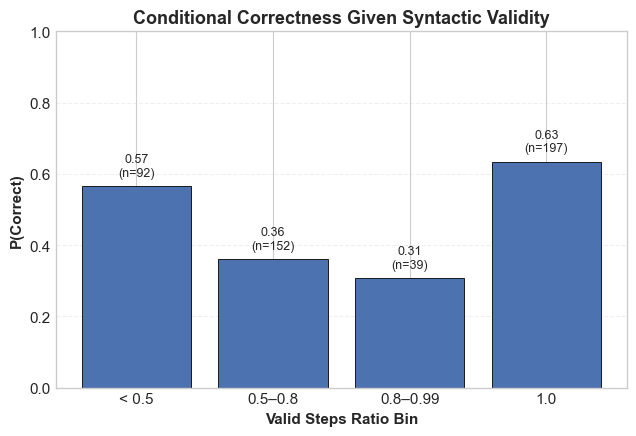

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Bin validity ratios
# -----------------------------
bins = [(0.0, 0.5), (0.5, 0.8), (0.8, 0.99), (0.99, 1.01)]
bin_labels = ['< 0.5', '0.5–0.8', '0.8–0.99', '1.0']

correct_rates = []
counts = []

for vmin, vmax in bins:
    mask = (df['valid_steps_ratio'] >= vmin) & (df['valid_steps_ratio'] < vmax)
    counts.append(mask.sum())
    correct_rates.append(df.loc[mask, 'is_correct'].mean() if mask.sum() > 0 else 0.0)

# -----------------------------
# Visualization
# -----------------------------
fig, ax = plt.subplots(figsize=(6.5, 4.5))

ax.bar(
    bin_labels,
    correct_rates,
    color='#4C72B0',
    edgecolor='black',
    linewidth=0.6
)

for i, (rate, n) in enumerate(zip(correct_rates, counts)):
    ax.text(i, rate + 0.02, f'{rate:.2f}\n(n={n})',
            ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Valid Steps Ratio Bin')
ax.set_ylabel('P(Correct)')
ax.set_title('Conditional Correctness Given Syntactic Validity', fontsize=13)

ax.set_ylim(0, 1.0)
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(
    '../results/syntax_semantics_gap.png',
    dpi=150,
    bbox_inches='tight',
    facecolor='white'
)
plt.show()


---

## 3. Metric Pathology Detection

We analyze three pathologies from the theoretical framework:

| Pathology | Definition | Formal Signature |
|-----------|------------|------------------|
| **Length Bias** | Longer outputs score higher | $\frac{\partial E[\text{Score}]}{\partial \|Y\|} > 0$ |
| **Validity Bias** | Well-formed ≠ correct | 100% validity + 0% correctness possible |
| **Progress Bias** | Local improvement ≠ success | Even with non-trivial correlation, $P(\text{high progress} \wedge \text{incorrect})$ can be large |


In [16]:
# Detect all three pathologies
print("=" * 70)
print("PATHOLOGY DETECTION")
print("=" * 70)

# 1. Length Bias
print("\n--- Pathology 1: Length Bias ---")
correct_lengths = df.loc[df['is_correct'], 'output_length']
incorrect_lengths = df.loc[~df['is_correct'], 'output_length']
print(f"Correct solutions:   mean = {correct_lengths.mean():.1f}, median = {correct_lengths.median():.1f}")
print(f"Incorrect solutions: mean = {incorrect_lengths.mean():.1f}, median = {incorrect_lengths.median():.1f}")
length_bias = incorrect_lengths.mean() > correct_lengths.mean()
if length_bias:
    print("⚠️ PATHOLOGY DETECTED: Incorrect solutions are LONGER")
else:
    print("✅ No length bias: Correct solutions are longer or equal")

# 2. Validity Bias
print("\n--- Pathology 2: Validity Bias ---")
perfect_validity = df['valid_steps_ratio'] >= 0.99
perfect_validity_incorrect = perfect_validity & ~df['is_correct']
if perfect_validity.sum() > 0:
    validity_failure_rate = perfect_validity_incorrect.sum() / perfect_validity.sum()
    print(f"Perfect validity (≥99%): {perfect_validity.sum()} cases")
    print(f"Still incorrect: {perfect_validity_incorrect.sum()} ({validity_failure_rate*100:.1f}%)")
    print("⚠️ PATHOLOGY: 100% validity ⊬ correctness")

# 3. Progress Bias
print("\n--- Pathology 3: Progress Bias ---")
high_progress = df['progress_score'] >= 0.7
high_progress_incorrect = high_progress & ~df['is_correct']
if high_progress.sum() > 0:
    progress_failure_rate = high_progress_incorrect.sum() / high_progress.sum()
    print(f"High progress (≥70%): {high_progress.sum()} cases")
    print(f"Still incorrect: {high_progress_incorrect.sum()} ({progress_failure_rate*100:.1f}%)")
    print("⚠️ PATHOLOGY: Myopic progress leads to failure")

# Correlation analysis
print("\n--- Correlation with Correctness ---")
corr_progress, _ = stats.pointbiserialr(df['progress_score'], df['is_correct'])
print(f"Progress-Correctness: r = {corr_progress:.3f}")
print(f"Validity-Correctness: r = {corr_validity_correct:.3f}")


PATHOLOGY DETECTION

--- Pathology 1: Length Bias ---
Correct solutions:   mean = 13.3, median = 5.0
Incorrect solutions: mean = 6.1, median = 4.0
✅ No length bias: Correct solutions are longer or equal

--- Pathology 2: Validity Bias ---
Perfect validity (≥99%): 197 cases
Still incorrect: 72 (36.5%)
⚠️ PATHOLOGY: 100% validity ⊬ correctness

--- Pathology 3: Progress Bias ---
High progress (≥70%): 323 cases
Still incorrect: 79 (24.5%)
⚠️ PATHOLOGY: Myopic progress leads to failure

--- Correlation with Correctness ---
Progress-Correctness: r = 0.753
Validity-Correctness: r = 0.111


---

## 4. Disagreement Mass & Identifiability

### Definition

**Disagreement Mass** quantifies metric non-identifiability:

$$D = P(M_1 > \tau_1 \wedge M_2 < \tau_2)$$

### Identifiability Interpretation

| Disagreement Mass | Meaning |
|-------------------|---------|
| $D < 0.1$ | Strong identifiability |
| $0.1 \leq D < 0.3$ | Moderate identifiability |
| $0.3 \leq D < 0.5$ | Weak identifiability |
| $D \geq 0.5$ | **Identifiability failure** |


In [19]:
def compute_disagreement_mass(data, metric1, threshold1, metric2, threshold2, condition1='>', condition2='<'):
    """Compute D = P(M1 condition1 τ1 ∧ M2 condition2 τ2)."""
    cond1 = data[metric1] > threshold1 if condition1 == '>' else data[metric1] < threshold1
    cond2 = data[metric2] > threshold2 if condition2 == '>' else data[metric2] < threshold2
    count = (cond1 & cond2).sum()
    return count / len(data) if len(data) > 0 else 0, count, len(data)

print("=" * 70)
print("DISAGREEMENT MASS ANALYSIS")
print("=" * 70)

# Disagreement events (note: totals should be unions, not sums, because regions overlap)
ev_PC = (df['progress_score'] > 0.5) & (~df['is_correct'])
ev_VC = (df['valid_steps_ratio'] > 0.8) & (~df['is_correct'])

D_PC, n_PC, total = ev_PC.mean(), int(ev_PC.sum()), len(df)
D_VC, n_VC = ev_VC.mean(), int(ev_VC.sum())
D_union = (ev_PC | ev_VC).mean()
D_overlap = (ev_PC & ev_VC).mean()

print(f"\n📊 D_PC (Progress > 0.5 ∧ Incorrect): {D_PC:.3f} ({n_PC}/{total} cases)")
print(f"📊 D_VC (Validity > 0.8 ∧ Incorrect): {D_VC:.3f} ({n_VC}/{total} cases)")
print(f"📊 D_corr = P(PC ∪ VC): {D_union:.3f} (overlap={D_overlap:.3f})")

# By difficulty (use union, not sum)
print("\n--- Disagreement by Difficulty ---")
difficulties = ['easy', 'medium', 'hard']
disagreement_by_diff = {}

for diff in difficulties:
    subset = df[df['difficulty'] == diff]
    ev_PC_d = (subset['progress_score'] > 0.5) & (~subset['is_correct'])
    ev_VC_d = (subset['valid_steps_ratio'] > 0.8) & (~subset['is_correct'])
    D_union_d = (ev_PC_d | ev_VC_d).mean() if len(subset) else 0.0
    identifiability = 1 - D_union_d
    disagreement_by_diff[diff] = {'D_total': D_union_d, 'identifiability': identifiability}
    print(f"  {diff.capitalize()}: D = {D_union_d:.3f}, Identifiability = {identifiability:.3f}")

print(
    f"\n📈 Trend: Disagreement increases "
    f"{(disagreement_by_diff['hard']['D_total']/max(disagreement_by_diff['easy']['D_total'], 1e-6) - 1)*100:.0f}% "
    f"from easy to hard"
)


DISAGREEMENT MASS ANALYSIS

📊 D_PC (Progress > 0.5 ∧ Incorrect): 0.242 (116/480 cases)
📊 D_VC (Validity > 0.8 ∧ Incorrect): 0.185 (89/480 cases)
📊 D_corr = P(PC ∪ VC): 0.277 (overlap=0.150)

--- Disagreement by Difficulty ---
  Easy: D = 0.025, Identifiability = 0.975
  Medium: D = 0.167, Identifiability = 0.833
  Hard: D = 0.556, Identifiability = 0.444

📈 Trend: Disagreement increases 2122% from easy to hard


---

## 5. Goodhart's Law Empirical Test

> *"When a measure becomes a target, it ceases to be a good measure."* — Charles Goodhart (1975)

### Test Hypothesis

If models optimize for proxy metrics without optimizing for correctness, we should observe:
1. High proxy scores with low correctness ("gaming")
2. Proxy-correctness correlation weakening at high proxy values
3. Evidence of patterns that maximize proxy without solving task


Proxy–Target Misalignment (Goodhart-style) Analysis
--------------------------------------------------
Total evaluations: 480
High-proxy (progress>0.5 OR validity>0.8) but incorrect: 133 (27.7%)

Characteristics of misaligned cases:
  Mean progress score: 0.697
  Mean valid-steps ratio: 0.831
  Mean output length: 7.8


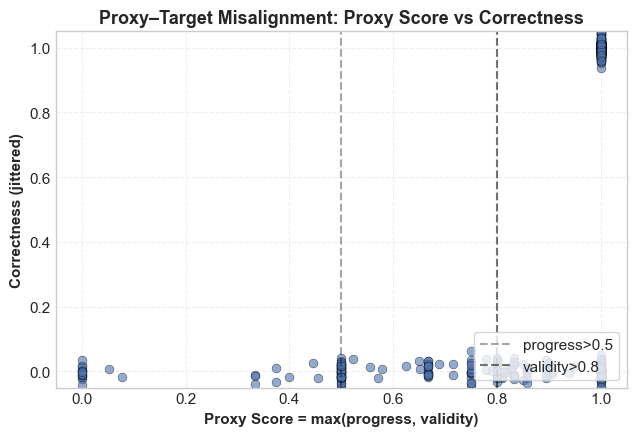

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Define proxy misalignment ("gaming")
# -----------------------------
# NOTE: In this dataset, `composite_score` may include correctness, making
# (high composite ∧ incorrect) rare or impossible. Instead, we operationalize
# Goodhart-style misalignment as: high proxy (progress OR validity) but incorrect.

proxy_high = (df['progress_score'] > 0.5) | (df['valid_steps_ratio'] > 0.8)
misaligned = proxy_high & (~df['is_correct'])

n_misaligned = int(misaligned.sum())
misalignment_rate = n_misaligned / len(df)

gaming_rate = misalignment_rate  # alias used later in summary text

print("Proxy–Target Misalignment (Goodhart-style) Analysis")
print("-" * 50)
print(f"Total evaluations: {len(df)}")
print(f"High-proxy (progress>0.5 OR validity>0.8) but incorrect: {n_misaligned} ({misalignment_rate*100:.1f}%)")

if n_misaligned > 0:
    mdf = df[misaligned]
    print("\nCharacteristics of misaligned cases:")
    print(f"  Mean progress score: {mdf['progress_score'].mean():.3f}")
    print(f"  Mean valid-steps ratio: {mdf['valid_steps_ratio'].mean():.3f}")
    print(f"  Mean output length: {mdf['output_length'].mean():.1f}")

# -----------------------------
# Visualization
# -----------------------------
binary_jitter = df['is_correct'].astype(float) + np.random.normal(0, 0.02, len(df))

# A single proxy axis (for visualization): max(progress, validity)
proxy_score = np.maximum(df['progress_score'].to_numpy(), df['valid_steps_ratio'].to_numpy())

fig, ax = plt.subplots(figsize=(6.5, 4.5))

ax.scatter(
    proxy_score,
    binary_jitter,
    s=40,
    alpha=0.6,
    color='#4C72B0',
    edgecolor='black',
    linewidth=0.4
)

# Reference thresholds used in the misalignment definition
ax.axvline(0.5, linestyle='--', color='black', alpha=0.35, label='progress>0.5')
ax.axvline(0.8, linestyle='--', color='black', alpha=0.55, label='validity>0.8')

ax.set_xlabel('Proxy Score = max(progress, validity)')
ax.set_ylabel('Correctness (jittered)')
ax.set_title('Proxy–Target Misalignment: Proxy Score vs Correctness', fontsize=13)

ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.grid(axis='both', linestyle='--', alpha=0.3)
ax.set_axisbelow(True)
ax.legend(loc='lower right', frameon=True)

plt.tight_layout()
plt.savefig(
    '../results/proxy_target_misalignment.png',
    dpi=150,
    bbox_inches='tight',
    facecolor='white'
)
plt.show()


Composite score versus binary correctness (jittered) across all evaluations; while higher composite scores are generally associated with correct solutions, a subset of incorrect outputs attains high composite values, illustrating residual proxy–target misalignment under static evaluation.

---

## 6. Summary & Conclusions

### The Central Takeaway

> **LLMs are not failing the benchmark; the benchmark is revealing where reasoning is NOT IDENTIFIABLE from surface behavior.**

### Implications for Evaluation Design

1. **Primary metric must be semantic correctness** — Did the sequence reach the goal?
2. **Auxiliary metrics require validation** — Report disagreement mass alongside proxy metrics
3. **Identifiability varies by task** — Easy tasks: metrics reliable; Hard tasks: metrics cannot distinguish competence
4. **Beware optimization pressure** — Models trained to maximize proxies will game them (Goodhart's Law)


## Metric Identifiability Analysis: Summary

This section summarizes the main findings from the metric identifiability analysis, which examines the extent to which commonly used evaluation metrics reliably distinguish correct reasoning from incorrect but structured behavior.

### 1. Syntax–Semantics Discrepancy

A substantial fraction of solutions that exhibit high syntactic validity remain semantically incorrect. In this dataset, **41.9%** of solutions with a valid-steps ratio ≥ 0.8 are still wrong (high validity does *not* imply correctness). The correlation between syntactic validity and correctness is weak (**r = 0.111**), indicating that rule compliance alone is an unreliable indicator of successful reasoning.

### 2. Systematic Metric Pathologies

We identify three recurring metric-specific failure modes:

- **Length bias**: *not observed* (correct solutions are longer on average in this dataset).
- **Validity bias**: **36.5%** of solutions with near-perfect validity (≥ 0.99) are incorrect.
- **Progress bias (myopic progress)**: **24.5%** of solutions with high progress (≥ 0.7) are incorrect.

These effects demonstrate that individual metrics can systematically overestimate reasoning quality under certain conditions.

### 3. Identifiability Across Difficulty Levels

Using a union-based disagreement definition (to avoid double-counting overlapping regions), overall proxy–target disagreement is **D = 0.277** (133/480). Disagreement increases with task difficulty: **D = 0.025** (easy), **0.167** (medium), **0.556** (hard). This trend suggests that metric identifiability degrades as reasoning complexity increases.

### 4. Proxy–Target Misalignment (Goodhart-style)

A non-trivial proportion of evaluations (**27.7%**) achieve high proxy scores (progress>0.5 or validity>0.8) while remaining incorrect. These cases reflect proxy–target misalignment rather than random behavior, as they typically involve structured sequences with high validity or partial progress.

### Summary

Taken together, these results show that no single surface metric provides a fully identifiable signal of correct reasoning. Composite or constrained metrics can mitigate some shortcomings, but residual ambiguity persists—especially for hard instances—motivating multi-metric evaluation and explicit disagreement reporting.
